In [1]:
#导入一些包
import jqdatasdk
from jqdatasdk import *
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import copy as copy

#更改系统的默认编码
import importlib,sys
importlib.reload(sys)

d:\Anaconda3.1\lib\site-packages\pandas\compat\_optional.py:138: UserWarning: Pandas requires version '2.7.0' or newer of 'numexpr' (version '2.6.8' currently installed).
  warnings.warn(msg, UserWarning)


<module 'sys' (built-in)>

In [2]:
import os
path = os.getcwd()
a_path = os.path.join(path, "contract_info.csv")

In [3]:
#先用2015年的数据回测
#导入2015年的数据
contract_info2015=pd.read_csv(os.path.join(path, "contract_info.csv"),index_col=0)#index是数值
contract_price2015=pd.concat([pd.read_csv(os.path.join(path, "contract_price2015.csv"),index_col=0),
                              pd.read_csv(os.path.join(path, "contract_price2015_1.csv"),index_col=0),
                              pd.read_csv(os.path.join(path, "contract_price2015_2.csv"),index_col=0),
                              pd.read_csv(os.path.join(path, "contract_price2015_3.csv"),index_col=0),
                              pd.read_csv(os.path.join(path, "contract_price2015_4.csv"),index_col=0),
                              pd.read_csv(os.path.join(path, "contract_price2015_5.csv"),index_col=0)])#index是数值
etf_cls2015=pd.read_csv(os.path.join(path, "etf50_info2015-2022.csv"),index_col=0) #index是时间戳
etf_cls2015

,close,open,high,low
2015-01-05,2.365,2.327,2.395,2.304
2015-01-06,2.338,2.345,2.391,2.310
2015-01-07,2.334,2.322,2.365,2.307
2015-01-08,2.271,2.344,2.354,2.264
2015-01-09,2.276,2.264,2.385,2.251
...,...,...,...,...
2022-10-28,2.365,2.403,2.419,2.360
2022-10-31,2.333,2.344,2.365,2.321
2022-11-01,2.436,2.342,2.438,2.342
2022-11-02,2.456,2.422,2.476,2.415


In [4]:
#获取交易日
def get_trade_days(trade_data,start_date,end_date): 
    #trade_data要求是Series数据，index=时间戳，开始日期和结束日期是str
    trade_days=pd.to_datetime(trade_data.truncate(before=start_date,after=end_date))
    return trade_days

In [6]:
#定义查询函数
def get_contract_info_small(contract_info_big,trade_date,interval_days):
    tem_list=[]
    for i in range(len(contract_info_big)):#遍历所有df的行
        if interval_days>(pd.to_datetime(contract_info_big['expire_date'][i])-pd.to_datetime(trade_date)).days and pd.to_datetime(contract_info_big['list_date'][i])<pd.to_datetime(trade_date) and pd.to_datetime(contract_info_big['expire_date'][i])>pd.to_datetime(trade_date):
        
        #如果距离到期小于interval(一般30天),且发行日<交易日<到期日
           tem_list.append(i) #记录所有满足条件的行
    contract_info_small=contract_info_big.loc[tem_list,:]
    contract_info_small_po=copy.deepcopy(contract_info_small)
    contract_info_small_po=contract_info_small_po.loc[contract_info_small_po['contract_type']=='PO']
    contract_info_small_po=contract_info_small_po.reset_index()
    return contract_info_small_po

In [7]:
#定义计算波动率的函数
import math as math
import scipy.stats as sta
#bs公式
def bs_put_value(target_price, strike_price, rf_rate, maturity, volatility): 
    #target_price标的证券的当前价格, strike_price期权的行权价, rf_rate无风险利率, maturity期权有效期限,volatility隐含波动率
    d1 = math.log(target_price/strike_price, math.e) + (rf_rate + 0.5*math.pow(volatility, 2))*maturity
    d1 = d1/(volatility * maturity ** 0.5)
    d2 = d1 - volatility * maturity ** 0.5
    put_value = strike_price * pow(math.e, -rf_rate * maturity) * (1-sta.norm.cdf(d2, 0, 1))-target_price * (1-sta.norm.cdf(d1, 0, 1))
    return put_value
#求解公式：计算波动率的函数
def solution_bs(contract_info,contract_price,target_price,rf_rate):
    tem_list = []
    contract_info_add_volatilty=copy.deepcopy(contract_info)
    for i in range(len(contract_info['code'])):        
        strike_price = contract_info['exercise_price'].values        
        maturity = (pd.to_datetime(contract_info['expire_date'])-pd.to_datetime(contract_info['list_date'])).apply(lambda x : x.days)
        put_value = contract_price['open'].values
        volatility = 0
        while True:
            volatility += 0.0001
            if  abs(bs_put_value(target_price, strike_price[i], rf_rate, maturity[i], volatility) - put_value[i]) <= 0.001:
                break
            if volatility > 0.4: # 重写
                break
        tem_list.append(volatility)
    contract_info_add_volatilty['volatility']=tem_list
    return contract_info_add_volatilty


In [8]:
#定义价格查询函数
def get_contract_price_small(contract_price_big,trade_date):
    contract_price_small=contract_price_big.loc[pd.to_datetime(contract_price_big['date'])==pd.to_datetime(trade_date)]
    return contract_price_small

In [9]:
#定义直接选择期权的函数
def chooce_contract_easy(contract_info_small,contract_price_samll,etf_cls,rf_rate,min_volatility,max_volatility,date,holding_contract): #df,df,float,float,float,str,Series
    #计算波动率
    contract_info=contract_info_small
    etf_cls= pd.Series(etf_cls['open'].values, index=etf_cls.index)
    target_price=etf_cls[date]
    contract_price=contract_price_samll
    contract_info_add_volatilty_easy=solution_bs(contract_info=contract_info,contract_price=contract_price,target_price=target_price,rf_rate=rf_rate)
    tem_list_easy=contract_info_add_volatilty_easy['volatility'].values.tolist()
    #判断范围内期权是否存在，选择期权买入
    if all(min_volatility<=_ <=max_volatility for _ in tem_list_easy)==True:
        contract_info_add_volatilty_easy= contract_info_add_volatilty_easy.sort_values('volatility',ascending=False)
        holding_contract[date]=contract_info_add_volatilty_easy['code'].iloc[0]
        newest_expire_date=contract_info_add_volatilty_easy['last_trade_date'].iloc[0]
    else:
        contract_info_add_volatilty_easy_spread=copy.deepcopy(contract_info_add_volatilty_easy)
        contract_info_add_volatilty_easy_spread['spread']=abs(max_volatility-contract_info_add_volatilty_easy['volatility'])
        contract_info_add_volatilty_easy_spread=contract_info_add_volatilty_easy_spread.sort_values('spread',ascending=True)
        holding_contract[date]=contract_info_add_volatilty_easy_spread['code'].iloc[0]
        newest_expire_date=contract_info_add_volatilty_easy['last_trade_date'].iloc[0]
    return holding_contract,newest_expire_date


In [10]:
#定义选择前几个交易日的函数
def getLastTradeDay(tradeDatList,nowDate,lastNumer):
    position = tradeDatList.tolist().index(nowDate)
    if position == 0:
        return tradeDatList[0]
    else:
        return tradeDatList[int(position-lastNumer)]

In [11]:
#定义止盈止损和判断是否要中途换期权追逐利益的函数
def chooce_contract_hard(contract_info_small,contract_price_small_hard,etf_cls_hard,rf_rate_hard,min_volatility_hard,max_volatility_hard,date_hard,holding_contract,spred_rate,tradeDatList,nowDate_hard):
    #计算波动率
    contract_info=contract_info_small
    etf_cls_test= pd.Series(etf_cls_hard['open'].values, index=etf_cls_hard.index)
    target_price=etf_cls_test[date_hard]
    contract_price=contract_price_small_hard
    contract_info_add_volatilty_hard=solution_bs(contract_info=contract_info,contract_price=contract_price,target_price=target_price,rf_rate=rf_rate_hard)
    tem_list_hard=contract_info_add_volatilty_hard['volatility'].values.tolist()

    lastTradeDay = getLastTradeDay(tradeDatList,nowDate_hard,1)
    
    if contract_info_add_volatilty_hard['volatility'].loc[contract_info_add_volatilty_hard['code']==str(holding_contract[lastTradeDay])].tolist()==[]: 
        
        holding_contract,newest_expire_date=chooce_contract_easy(contract_info_small,contract_price_samll=contract_price_small_hard,etf_cls=etf_cls_hard,rf_rate=rf_rate_hard,min_volatility=min_volatility_hard,max_volatility=max_volatility_hard,date=date_hard,holding_contract=holding_contract)
    else: #不需要止盈止损
        holding_contract,newest_expire_date=chooce_contract_easy(contract_info_small,contract_price_samll=contract_price_small_hard,etf_cls=etf_cls_hard,rf_rate=rf_rate_hard,min_volatility=min_volatility_hard,max_volatility=max_volatility_hard,date=date_hard,holding_contract=holding_contract)
        newest_volatility=contract_info_add_volatilty_hard['volatility'].loc[contract_info_add_volatilty_hard['code']==str(holding_contract[lastTradeDay])].values[0] 
        if all(min_volatility_hard<=_ <=max_volatility_hard and _ >newest_volatility for _ in tem_list_hard)==True:
            contract_info_add_volatilty_hard= contract_info_add_volatilty_hard.sort_values('volatility',ascending=False)
            for j in range(len(contract_info_add_volatilty_hard['volatility'])):
                original_open= contract_price_small_hard['open'].loc[contract_price_small_hard['code'] == str(holding_contract[lastTradeDay])] 
                spread_rate=(10000*(original_open-contract_price_small_hard['open'].iloc[j])-5)/(contract_price_small_hard['open'].iloc[j]*100000+5)
                
                if spread_rate>=spred_rate:
                    holding_contract[date_hard]=contract_info_add_volatilty_hard['code'].iloc[j]
                    newest_expire_date=contract_info_add_volatilty_hard['last_trade_date'].iloc[j] #到期日更新
                else:

                    holding_contract[date_hard]=holding_contract[lastTradeDay]
                    newest_expire_date=newest_expire_date # 到期日更新
        else: 
            holding_contract[date_hard]=holding_contract[lastTradeDay]
            newest_expire_date=newest_expire_date
    
        
    return holding_contract,newest_expire_date

In [13]:
#完整策略循环
etf_cls2015_Series=pd.Series(index=etf_cls2015.index)
trade_days=get_trade_days(trade_data=etf_cls2015_Series,start_date='2015-03-24',end_date='2015-04-22') # 'xxxx-xx-xx'

holding_contract=pd.Series(pd.Series(index=trade_days.index))

trade_days_index = trade_days.index[0:]
for i in trade_days_index:
    if i==trade_days_index[0]: #如果是第一天就开启简单挑选期权模式
        contract_info_small_1= get_contract_info_small(contract_info_big=contract_info2015,trade_date=i,interval_days=60)
        contract_price_small_1=get_contract_price_small(contract_price2015,i)
        holding_contract,newest_expire_date_1=chooce_contract_easy(contract_info_small_1,contract_price_small_1,etf_cls=etf_cls2015,rf_rate=0.02478,min_volatility=0.18,max_volatility=0.3,date=i,holding_contract=holding_contract)
    else: #如果不是第一天
        #如果不是第一天且未到期
        temLatsDay3 = getLastTradeDay(tradeDatList = trade_days_index,nowDate = i,lastNumer = 3)
        newest_expire_date_1_last_3_day = getLastTradeDay(tradeDatList = trade_days_index,nowDate = newest_expire_date_1,lastNumer = 3)
        if pd.to_datetime(i)<= pd.to_datetime(pd.to_datetime(newest_expire_date_1_last_3_day)):
            #开启复杂挑选模式
            contract_info_small_1= get_contract_info_small(contract_info_big=contract_info2015,trade_date=i,interval_days=60)
            contract_price_small_1=get_contract_price_small(contract_price2015,i)
            holding_contract,newest_expire_date_1=chooce_contract_hard(contract_info_small_1,contract_price_small_1,etf_cls_hard=etf_cls2015,rf_rate_hard=0.02478,min_volatility_hard=0.18,max_volatility_hard=0.3,date_hard=i,holding_contract=holding_contract,spred_rate=0.01,tradeDatList=trade_days_index,nowDate_hard=i)
        #如果不是第一天但期权到期
        else:
            contract_info_small_1= get_contract_info_small(contract_info_big=contract_info2015,trade_date=i,interval_days=60)
            contract_price_small_1=get_contract_price_small(contract_price2015,i)
            holding_contract,newest_expire_date_1=chooce_contract_easy(contract_info_small_1,contract_price_small_1,etf_cls=etf_cls2015,rf_rate=0.02478,min_volatility=0.18,max_volatility=0.3,date=i,holding_contract=holding_contract)
            temLatsDay1 = getLastTradeDay(tradeDatList = trade_days_index,nowDate = i,lastNumer = 1)
            if holding_contract[i] ==holding_contract[temLatsDay1]:
                contract_price_small_1=contract_price_small_1.drop(contract_price_small_1[(contract_price_small_1.code==holding_contract[i] )].index,inplace=True)
    print(i)

holding_contract = holding_contract.fillna(method='ffill') #将最后一个有效的观察结果向前传播到下一个有效的
holding_contract


d:\Anaconda3.1\lib\site-packages\ipykernel_launcher.py:2: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  
d:\Anaconda3.1\lib\site-packages\ipykernel_launcher.py:5: DeprecationWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  """


2015-03-24
2015-03-25
2015-03-26
2015-03-27
2015-03-30
2015-03-31
2015-04-01
2015-04-02
2015-04-03
2015-04-07
2015-04-08
2015-04-09
2015-04-10
2015-04-13
2015-04-14
2015-04-15
2015-04-16
2015-04-17
2015-04-20
2015-04-21
2015-04-22


2015-03-24    10000020.XSHG
2015-03-25    10000020.XSHG
2015-03-26    10000020.XSHG
2015-03-27    10000020.XSHG
2015-03-30    10000020.XSHG
2015-03-31    10000020.XSHG
2015-04-01    10000020.XSHG
2015-04-02    10000020.XSHG
2015-04-03    10000020.XSHG
2015-04-07    10000020.XSHG
2015-04-08    10000020.XSHG
2015-04-09    10000020.XSHG
2015-04-10    10000020.XSHG
2015-04-13    10000020.XSHG
2015-04-14    10000020.XSHG
2015-04-15    10000020.XSHG
2015-04-16    10000020.XSHG
2015-04-17    10000020.XSHG
2015-04-20    10000060.XSHG
2015-04-21    10000052.XSHG
2015-04-22    10000122.XSHG
dtype: object

# 回测画图

In [14]:
data2 = pd.DataFrame(holding_contract)
data2.columns = ['holding_contract']
data2 = data2.reindex(columns=['holding_contract','open','last_open']) #重新定义columns

last_contract = holding_contract.iloc[0]   #记录上个持仓

for t in data2.index:
    this_contract = data2.loc[t,'holding_contract']
    if last_contract == data2.loc[t,'holding_contract']:  #期权未换仓
        #收盘价
        price = contract_price2015[(contract_price2015['code']== this_contract)&(contract_price2015['date']== t)]['open']
        data2.loc[t,'open'] = price.values[0]
    else:
        #收盘价,新
        price = contract_price2015[(contract_price2015['code']== this_contract)&(contract_price2015['date']== t)]['open']
        data2.loc[t,'open'] = price.values[0]
        #收盘价,旧
        price = contract_price2015[(contract_price2015['code']== last_contract)&(contract_price2015['date']== t)]['open']
        data2.loc[t,'last_open'] = price.values[0]

        last_contract = this_contract
        
data2       

,holding_contract,open,last_open
2015-03-24,10000020.XSHG,0.0106,NaN
2015-03-25,10000020.XSHG,0.0147,NaN
2015-03-26,10000020.XSHG,0.0173,NaN
2015-03-27,10000020.XSHG,0.0113,NaN
2015-03-30,10000020.XSHG,0.0086,NaN
2015-03-31,10000020.XSHG,0.0025,NaN
2015-04-01,10000020.XSHG,0.0048,NaN
2015-04-02,10000020.XSHG,0.0017,NaN
2015-04-03,10000020.XSHG,0.0048,NaN
2015-04-07,10000020.XSHG,0.0022,NaN


In [15]:
#卖出期权收益（值）
opt_ret2 = pd.Series(0,index=data2.index) #初始化一个Series
pre_close2 = data2['open'].iloc[0] #卖第一个期权的价格
for t in data2.index[1:]:
    if data2.isna().loc[t,'last_open']:   #未换仓,last为空
        opt_ret2[t] = -10000*(data2.loc[t,'open'] - pre_close2)
    else:
        opt_ret2[t] = -10000*(data2.loc[t,'last_open'] - pre_close2) - 5  #手续费5元
    pre_close2 = data2.loc[t,'open'] #重新定义“第一个”期权的卖出价
opt_ret2


2015-03-24     0
2015-03-25   -40
2015-03-26   -26
2015-03-27    60
2015-03-30    26
2015-03-31    60
2015-04-01   -22
2015-04-02    30
2015-04-03   -30
2015-04-07    25
2015-04-08    13
2015-04-09     3
2015-04-10    -4
2015-04-13     7
2015-04-14     1
2015-04-15    -1
2015-04-16     1
2015-04-17     0
2015-04-20    -6
2015-04-21    -5
2015-04-22    -5
dtype: int64

In [16]:
etf_cls2015

,close,open,high,low
2015-01-05,2.365,2.327,2.395,2.304
2015-01-06,2.338,2.345,2.391,2.310
2015-01-07,2.334,2.322,2.365,2.307
2015-01-08,2.271,2.344,2.354,2.264
2015-01-09,2.276,2.264,2.385,2.251
...,...,...,...,...
2022-10-28,2.365,2.403,2.419,2.360
2022-10-31,2.333,2.344,2.365,2.321
2022-11-01,2.436,2.342,2.438,2.342
2022-11-02,2.456,2.422,2.476,2.415


In [17]:
etf_cls2015

,close,open,high,low
2015-01-05,2.365,2.327,2.395,2.304
2015-01-06,2.338,2.345,2.391,2.310
2015-01-07,2.334,2.322,2.365,2.307
2015-01-08,2.271,2.344,2.354,2.264
2015-01-09,2.276,2.264,2.385,2.251
...,...,...,...,...
2022-10-28,2.365,2.403,2.419,2.360
2022-10-31,2.333,2.344,2.365,2.321
2022-11-01,2.436,2.342,2.438,2.342
2022-11-02,2.456,2.422,2.476,2.415


In [18]:
data2.index[-1]

'2015-04-22'

In [19]:
#50etf持仓收益（值）
etf_price=etf_cls2015.truncate(before=data2.index[0],after=data2.index[-1])['open']
etf_ret = 10000*etf_price.diff(1).fillna(0) #一阶差分
etf_ret

2015-03-24       0.0
2015-03-25    -420.0
2015-03-26    -360.0
2015-03-27     540.0
2015-03-30     220.0
2015-03-31     980.0
2015-04-01    -630.0
2015-04-02     600.0
2015-04-03    -480.0
2015-04-07     650.0
2015-04-08     510.0
2015-04-09     500.0
2015-04-10    -290.0
2015-04-13    1010.0
2015-04-14      10.0
2015-04-15      70.0
2015-04-16     220.0
2015-04-17    1950.0
2015-04-20    -330.0
2015-04-21    -840.0
2015-04-22     550.0
Name: open, dtype: float64

In [20]:
init_asset2 = etf_price.iloc[0]*10000 #初始持有资产
ass2 = init_asset2 + (etf_ret + opt_ret2).cumsum()
pfl_ret2 = (ass2/ass2.shift(1) - 1).fillna(0) #收益率
pfl_nv2 = (1 + pfl_ret2).cumprod() #累计收益率
pfl_nv2

2015-03-24    1.000000
2015-03-25    0.980944
2015-03-26    0.964954
2015-03-27    0.989809
2015-03-30    1.000000
2015-03-31    1.043082
2015-04-01    1.016073
2015-04-02    1.042171
2015-04-03    1.021044
2015-04-07    1.049006
2015-04-08    1.070671
2015-04-09    1.091508
2015-04-10    1.079329
2015-04-13    1.121458
2015-04-14    1.121914
2015-04-15    1.124772
2015-04-16    1.133927
2015-04-17    1.214706
2015-04-20    1.200787
2015-04-21    1.165783
2015-04-22    1.188360
dtype: float64

In [21]:
plt.rcParams['font.sans-serif']=['SimHei']

plt.rcParams['axes.unicode_minus'] = False

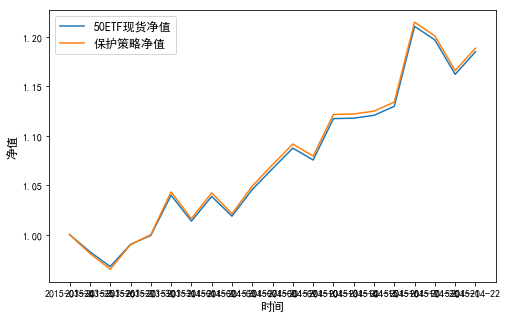

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(etf_price/etf_price.iloc[0], label='50ETF现货净值')
plt.plot(pfl_nv2, label='保护策略净值')
plt.legend(loc='upper left', fontsize='large')
plt.xlabel('时间',size=12)
plt.ylabel('净值',size=12)
plt.show()